Gradeint Boosting algorithm

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
RANDOM_STATE=42
sns.set_theme(style='whitegrid')

In [14]:
housing=fetch_california_housing(as_frame=True)
df=housing.frame.copy()
print(f'Shape: {df.shape}')
display(df.head())

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [15]:
print('Features:')
print(housing.feature_names)
print(f'\nTarget: {housing.target_names}')
display(df.describe().T)

Features:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target: ['MedHouseVal']


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


In [16]:
print('Missing vales:')
display(df.isna().sum().to_frame('missing'))
print(f'Duplicate rows: {df.duplicated().sum()}')

Missing vales:


,missing
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


Duplicate rows: 0


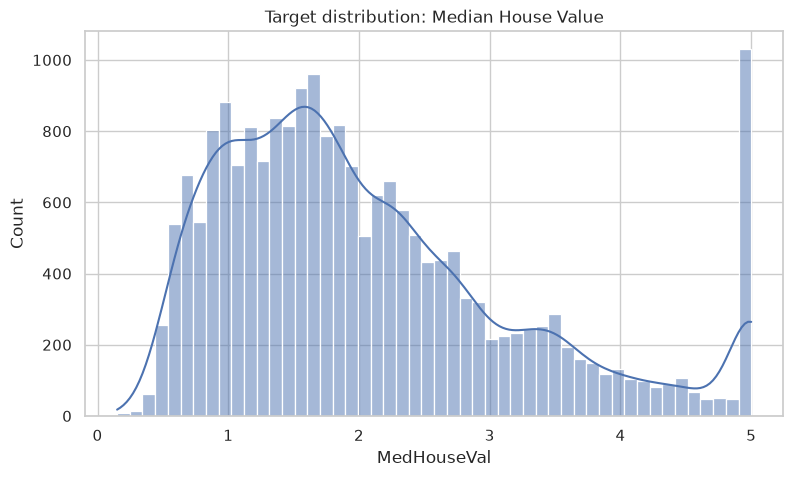

In [17]:
plt.figure(figsize=(9, 5))
sns.histplot(df['MedHouseVal'], bins=50, kde=True)
plt.title('Target distribution: Median House Value')
plt.xlabel('MedHouseVal')
plt.ylabel('Count')
plt.show()

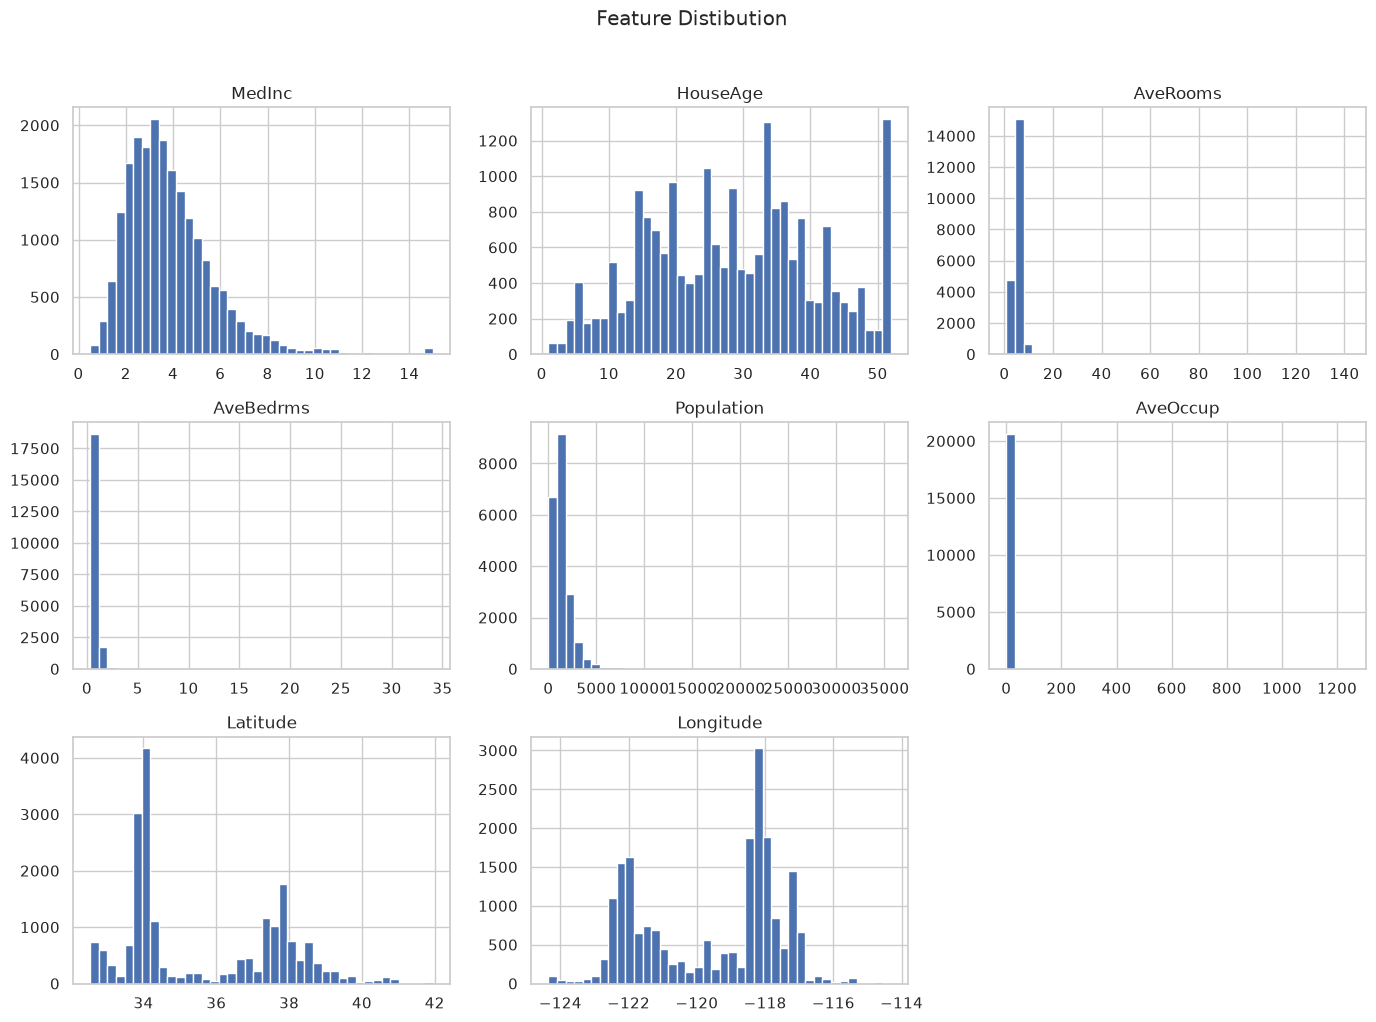

In [18]:
df.drop(columns='MedHouseVal').hist(bins=40, figsize=(14, 10), layout=(3, 3))
plt.suptitle('Feature Distibution', y=1.02)
plt.tight_layout()

Text(0.5, 1.0, 'Correlation Matrix')

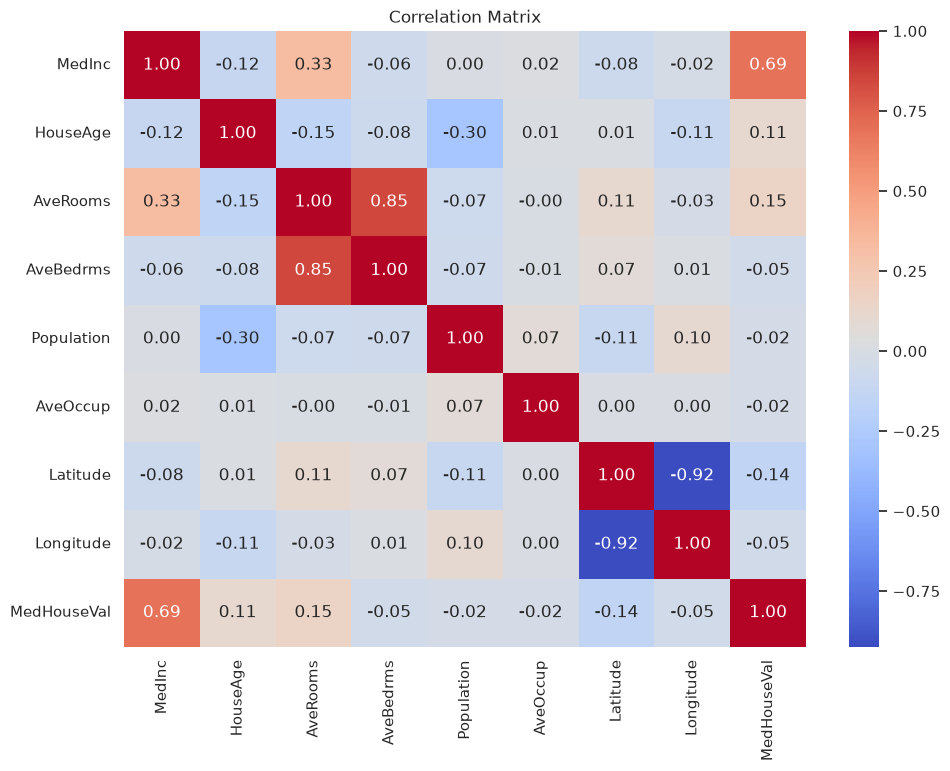

In [19]:
plt.figure(figsize=(11, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')

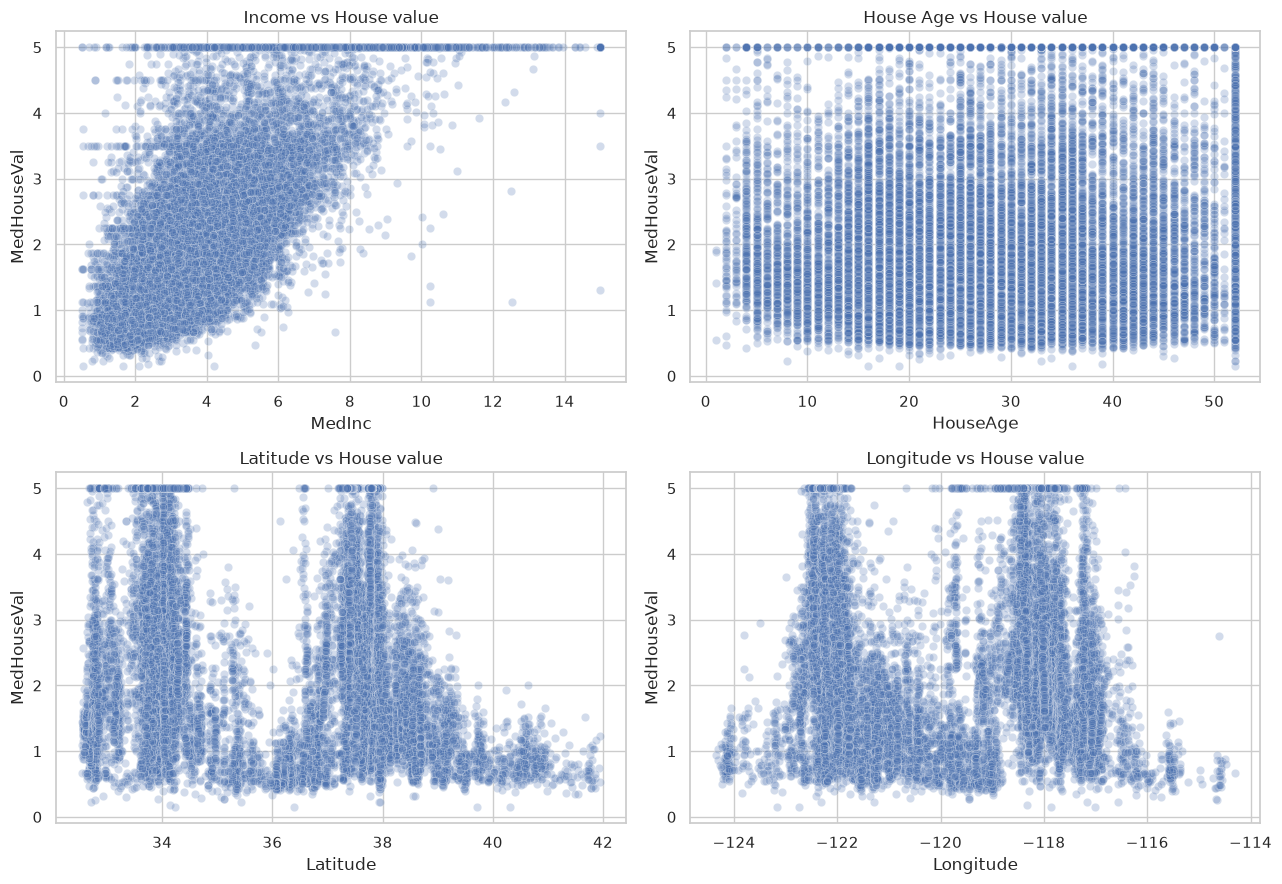

In [20]:
fig,axes=plt.subplots(2, 2, figsize=(13, 9))
sns.scatterplot(data=df, x='MedInc', y='MedHouseVal', alpha=0.25, ax=axes[0,0])
axes[0,0].set_title('Income vs House value')
sns.scatterplot(data=df, x='HouseAge', y='MedHouseVal', alpha=0.25, ax=axes[0,1])
axes[0,1].set_title('House Age vs House value')
sns.scatterplot(data=df, x='Latitude', y='MedHouseVal', alpha=0.25, ax=axes[1,0])
axes[1,0].set_title('Latitude vs House value')
sns.scatterplot(data=df, x='Longitude', y='MedHouseVal', alpha=0.25, ax=axes[1,1])
axes[1,1].set_title('Longitude vs House value')
plt.tight_layout()

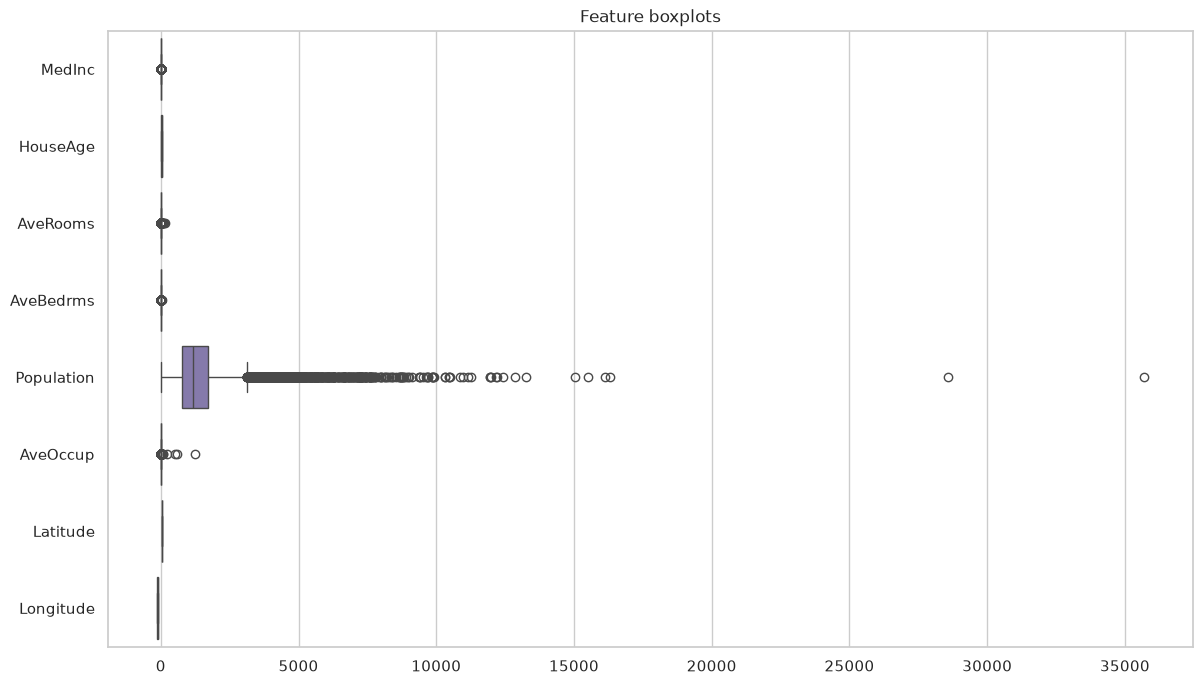

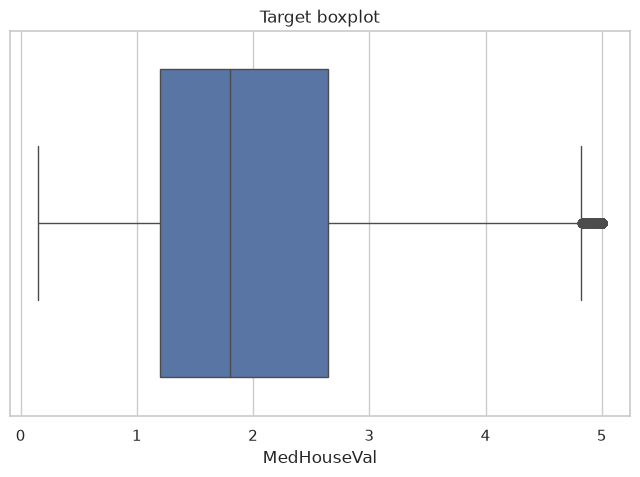

In [21]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df.drop(columns='MedHouseVal'), orient='h')
plt.title('Feature boxplots')
plt.show()
plt.figure(figsize=(8,5))
sns.boxplot(x=df['MedHouseVal'])
plt.title('Target boxplot')
plt.show()

In [22]:
x=df.drop(columns='MedHouseVal')
y=df['MedHouseVal']
X_train, X_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=RANDOM_STATE)
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (16512, 8)
X_test shape: (4128, 8)
y_train shape: (16512,)
y_test shape: (4128,)


In [23]:
def evalutate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    train_pred=model.predict(X_train)
    test_pred=model.predict(x_test)
    metrics={
        'Train MAE': mean_absolute_error(y_train, train_pred),
        'Test MAE': mean_absolute_error(y_test, test_pred),
        'Train MSE': mean_squared_error(y_train, train_pred),
        'Test MSE': mean_squared_error(y_test, test_pred),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_train, test_pred)),
        'Train R2 score': r2_score(y_train, train_pred),
        'Test R2 score': r2_score(y_test, test_pred)
    }
    return model, metrics, test_pred


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

data = fetch_california_housing(as_frame=True)
df = data.frame
print("Dataset shape:", df.shape)
print("\nBirinchi 5 ta qator")
display(df.head())

target = "MedHouseVal"

X = df.drop(columns=[target])
y = df[target]

print("\nFeatures")
print(X.columns.tolist())

print("\nTarget", target)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
model.fit(X_train, y_train)
print("\nModel training completed")

y_pred = model.predict(X_test)
print("\nFirst 10 predictions")
print(y_pred[:10])

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2 : {r2:.4f}")

residuals = y_test - y_pred

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by = "Importance",
    ascending=False
)

print("\nFeature Importance:")
display(feature_importance)

results = pd.DataFrame({
    "Actual":y_test.values,
    "Predicted":y_pred,
    "Residual":residuals.values
})

display(results.head(20))


print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2 : {r2:.4f}")

print("\nModel: Gradient Boosting Regressor")
print("Dataset: California Housing")
print("Target:", target)

Dataset shape: (20640, 9)

Birinchi 5 ta qator


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Features
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target MedHouseVal

Train shape: (16512, 8)
Test shape: (4128, 8)

Model training completed

First 10 predictions
[0.51673765 1.05572492 4.10546278 2.54111809 2.24676257 1.68371431
 2.34961135 1.72571681 3.05165712 4.36094439]
MAE : 0.3691
MSE : 0.2913
RMSE : 0.5397
R2 : 0.7777

Feature Importance:


,Feature,Importance
0,MedInc,0.603930
5,AveOccup,0.126155
7,Longitude,0.113820
6,Latitude,0.092933
1,HouseAge,0.033343
2,AveRooms,0.022692
3,AveBedrms,0.005252
4,Population,0.001875


,Actual,Predicted,Residual
0,0.47700,0.516738,-0.039738
1,0.45800,1.055725,-0.597725
2,5.00001,4.105463,0.894547
3,2.18600,2.541118,-0.355118
4,2.78000,2.246763,0.533237
5,1.58700,1.683714,-0.096714
6,1.98200,2.349611,-0.367611
7,1.57500,1.725717,-0.150717
8,3.40000,3.051657,0.348343
9,4.46600,4.360944,0.105056


MAE : 0.3691
MSE : 0.2913
RMSE : 0.5397
R2 : 0.7777

Model: Gradient Boosting Regressor
Dataset: California Housing
Target: MedHouseVal
